In [1]:
import numpy as np
import pandas as pd

In [2]:
seed0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed0_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed0["seed"] = [0 for i in range(len(seed0))]

In [3]:
seed1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed1_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed1["seed"] = [1 for i in range(len(seed1))]

In [4]:
seed2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed2_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed2["seed"] = [2 for i in range(len(seed2))]

In [5]:
seed3 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed3_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed3["seed"] = [3 for i in range(len(seed3))]

In [6]:
seed4 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed4_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed4["seed"] = [4 for i in range(len(seed4))]

In [7]:
seed5 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed5_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed5["seed"] = [5 for i in range(len(seed5))]

In [8]:
seed6 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed6_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed6["seed"] = [6 for i in range(len(seed6))]

In [9]:
seed7 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed7_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed7["seed"] = [7 for i in range(len(seed7))]

In [10]:
seed8 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed8_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed8["seed"] = [8 for i in range(len(seed8))]

In [11]:
seed9 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed9_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed9["seed"] = [9 for i in range(len(seed9))]

In [12]:
df = pd.concat([seed0, seed1, seed2, seed3, seed4, 
                seed5, seed6, seed7, seed8, seed9], ignore_index=True)

In [13]:
import ast

In [14]:
df['positions'] = df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [15]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [16]:
df = df[df["num_edits"] > 0]

In [17]:
df = df[df["URQ_diff"] < 0.0]

In [18]:
len(df)

377

In [19]:
def combine_positions_orientations(row):
    """Turn positions + orientations into set of tuples (start, end, strand)."""
    pos = row["positions"]
    ori = row["orientation"]
    return {(s, e, o) for (s, e), o in zip(pos, ori)}

In [20]:
# Make a new column with motif sets
df["motif_set"] = df.apply(combine_positions_orientations, axis=1)

In [21]:
import itertools

In [22]:
import matplotlib.pyplot as plt

In [23]:
region_cols = ['chrom', 'centered_start', 'centered_end']
region_keys = df[region_cols].drop_duplicates().to_dict('records')

results = []

for region in region_keys:
    region_df = df[
        (df['chrom'] == region['chrom']) &
        (df['centered_start'] == region['centered_start']) &
        (df['centered_end'] == region['centered_end'])
    ]
    
    seed_to_sites = {row['seed']: row['motif_set'] for _, row in region_df.iterrows()}

    for seed1, seed2 in itertools.combinations(sorted(seed_to_sites.keys()), 2):
        set1 = seed_to_sites[seed1]
        set2 = seed_to_sites[seed2]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        jaccard = intersection / union if union > 0 else float('nan')
        results.append({
            **region,
            'seed1': seed1,
            'seed2': seed2,
            'jaccard': jaccard
        })

jaccard_df = pd.DataFrame(results)

In [24]:
avg_jaccard_df = (
    jaccard_df
    .groupby(["chrom", "centered_start", "centered_end"])["jaccard"]
    .mean()
    .reset_index()
    .rename(columns={"jaccard": "avg_jaccard"})
)

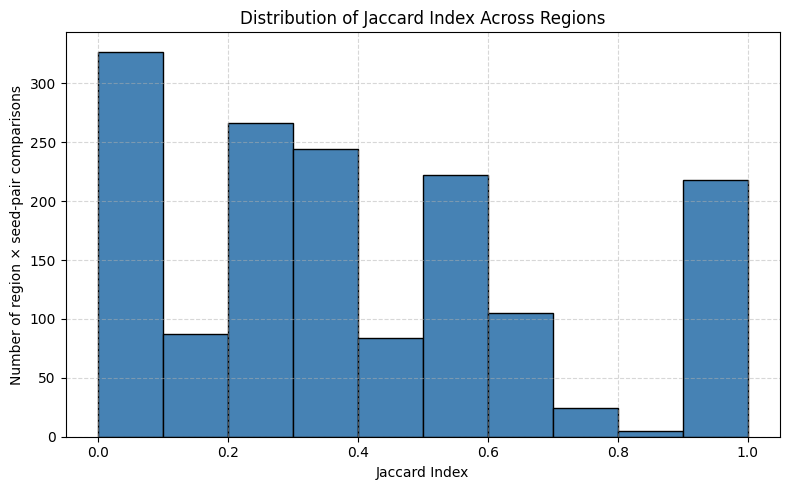

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(jaccard_df['jaccard'].dropna(), bins=10, color='steelblue', edgecolor='black')
plt.xlabel('Jaccard Index')
plt.ylabel('Number of region × seed-pair comparisons')
plt.title('Distribution of Jaccard Index Across Regions')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

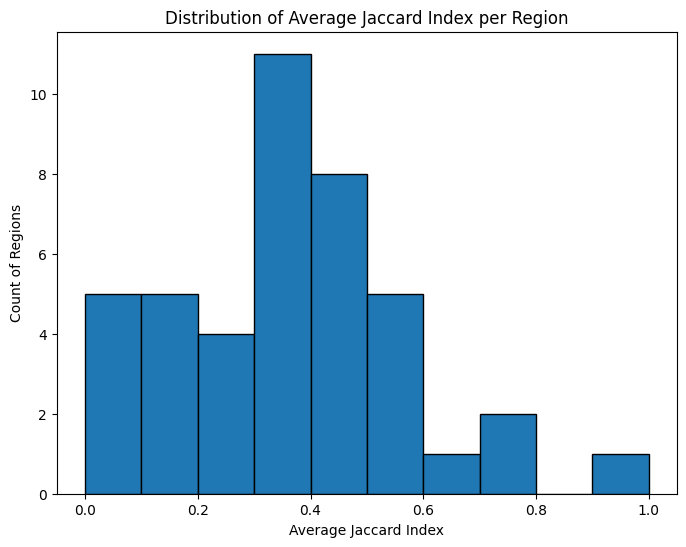

In [26]:
plt.figure(figsize=(8,6))
plt.hist(avg_jaccard_df["avg_jaccard"], bins=10, edgecolor="black")

plt.title("Distribution of Average Jaccard Index per Region")
plt.xlabel("Average Jaccard Index")
plt.ylabel("Count of Regions")
plt.show()

In [27]:
import random

region_keys = df[['chrom', 'centered_start', 'centered_end']].drop_duplicates()
random_regions = region_keys.sample(5, random_state=40).to_dict('records')

In [28]:
def get_jaccard_matrix_from_df(region, jaccard_df):
    region_mask = (
        (jaccard_df['chrom'] == region['chrom']) &
        (jaccard_df['centered_start'] == region['centered_start']) &
        (jaccard_df['centered_end'] == region['centered_end'])
    )
    sub_df = jaccard_df[region_mask]
    seeds = sorted(set(sub_df['seed1']) | set(sub_df['seed2']))
    matrix = pd.DataFrame(np.eye(len(seeds)), index=seeds, columns=seeds)

    for _, row in sub_df.iterrows():
        s1, s2 = row['seed1'], row['seed2']
        matrix.loc[s1, s2] = row['jaccard']
        matrix.loc[s2, s1] = row['jaccard']  # symmetric

    return matrix

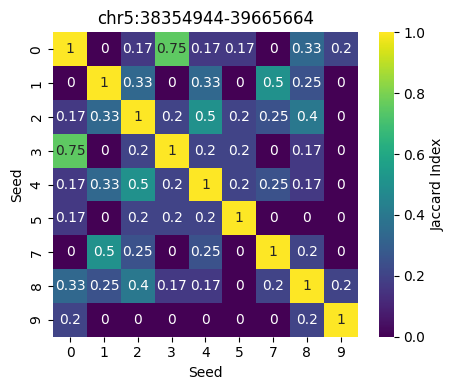

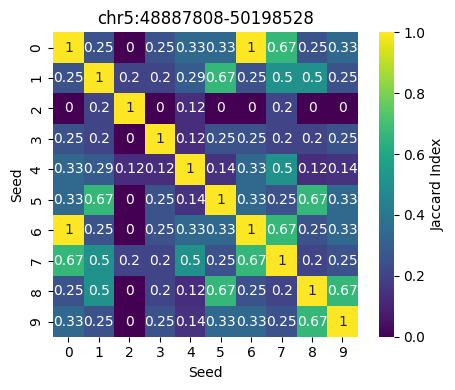

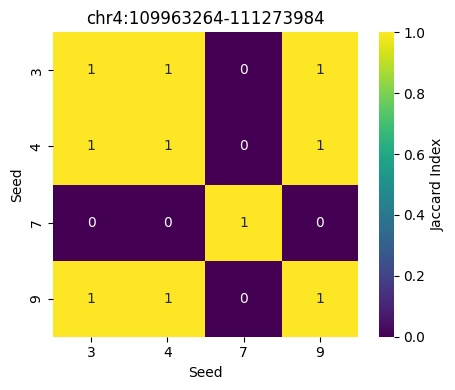

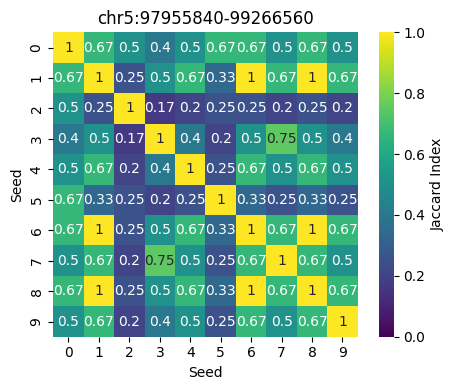

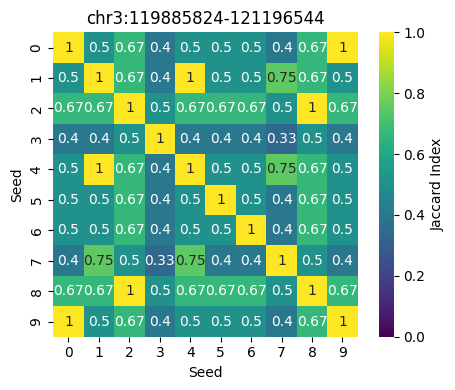

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

for region in random_regions:
    mat = get_jaccard_matrix_from_df(region, jaccard_df)

    plt.figure(figsize=(5, 4))
    sns.heatmap(mat, annot=True, cmap='viridis', vmin=0, vmax=1, square=True,
                xticklabels=mat.columns, yticklabels=mat.index,
                cbar_kws={'label': 'Jaccard Index'})
    plt.title(f"{region['chrom']}:{region['centered_start']}-{region['centered_end']}")
    plt.xlabel("Seed")
    plt.ylabel("Seed")
    plt.tight_layout()
    plt.show()

In [30]:
# collecting all CTCFs

import pandas as pd

bin_size = 2048
center_offset = 320 * bin_size
motif_len = 19

In [31]:
ctcf_records = []

for idx, row in df.iterrows():
    chrom = row['chrom']
    win_start = row['centered_start']
    win_end = row['centered_end']
    seed = row['seed']
    ctcf_sites = row['positions']
    orientations = list(row['orientation']) if isinstance(row['orientation'], str) else []

    if isinstance(ctcf_sites, str):
        try:
            ctcf_sites = eval(ctcf_sites)
        except:
            continue

    for i, (rel_start, rel_end) in enumerate(ctcf_sites):
        orientation = orientations[i] if i < len(orientations) else '?'
        ctcf_records.append({
            'chrom': chrom,
            'centered_start': win_start,
            'centered_end': win_end,
            'rel_start': rel_start,
            'rel_end': rel_end,
            'orientation': orientation,
            'seed': seed
        })

ctcf_df = pd.DataFrame(ctcf_records)


In [32]:
len(ctcf_df)

938

In [33]:
from tqdm import tqdm

In [34]:
# Count number of unique seeds in which each site appears
ctcf_seed_counts = (
    ctcf_df
    .groupby(['chrom', 'centered_start', 'centered_end', 'rel_start', 'rel_end', 'orientation'])
    .agg(seeds_present=('seed', 'nunique'))
    .reset_index()
)

In [35]:
ctcf_seed_counts['fraction_across_seeds'] = ctcf_seed_counts['seeds_present'] / 10

In [36]:
ctcf_seed_counts['genomic_start'] = ctcf_seed_counts['centered_start'] + center_offset + ctcf_seed_counts['rel_start']
ctcf_seed_counts['genomic_end'] = ctcf_seed_counts['centered_start'] + center_offset + ctcf_seed_counts['rel_end']

In [37]:
from pyfaidx import Fasta

In [38]:
from tqdm import tqdm

In [39]:
fasta_file = "/project2/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [40]:
def get_sequence(genome, chrom, start, end):
    seq = genome[chrom][start:end].seq.upper()
    return seq

In [41]:
def reverse_complement(seq: str) -> str:
    complement = str.maketrans("ACGTN", "TGCAN")  # include N if needed
    return seq.translate(complement)[::-1]

In [42]:
# estimating background probabilities

from collections import Counter

# Initialize counter
total_counts = Counter()
total_bases = 0

for _, row in avg_jaccard_df.iterrows():
    # read sequence from genome
    seq = get_sequence(genome, row["chrom"], row["centered_start"], row["centered_end"])
    seq = seq.upper()
    
    # count nucleotides in this sequence
    counts = Counter(seq)
    
    # keep only A/C/G/T
    for b in "ACGT":
        total_counts[b] += counts.get(b, 0)
    
    # accumulate total base count
    total_bases += sum(counts[b] for b in "ACGT")

# calculate background probabilities
bg_probs = {b: total_counts[b] / total_bases for b in "ACGT"}
print("Estimated background probabilities:", bg_probs)

Estimated background probabilities: {'A': 0.29268879286791105, 'C': 0.20697288889154505, 'G': 0.20722222477544558, 'T': 0.2931160934650983}


In [43]:
collected_ctcfs = []

for _, row in tqdm(ctcf_seed_counts.iterrows(), total=len(ctcf_seed_counts)):
    chrom = row["chrom"]
    genomic_start = row["genomic_start"]
    genomic_end = row["genomic_end"]
    orientation = row["orientation"]
    
    ctcf_seq = get_sequence(genome, chrom, genomic_start, genomic_end)
    
    if orientation == "-":
        ctcf_seq = reverse_complement(ctcf_seq)
        
    collected_ctcfs.append(ctcf_seq)

100%|██████████| 367/367 [00:00<00:00, 27792.90it/s]


In [44]:
def seq_score(seq, pwm, bg=None, pseudocount=1e-9):
    """
    seq: DNA sequence (string)
    pwm: numpy array of shape (length, 4)
    bg: dict of background probabilities, e.g., {'A':0.29, 'C':0.21, 'G':0.21, 'T':0.29}
    pseudocount: small value to avoid log(0)
    """
    if bg is None:
        bg = {'A':0.25, 'C':0.25, 'G':0.25, 'T':0.25}

    base_idx = {'A':0, 'C':1, 'G':2, 'T':3}
    score = 0.0
    seq = seq.upper()
    
    for i, b in enumerate(seq):
        if b not in base_idx:
            continue  # skip Ns or unexpected bases
        p = pwm[i, base_idx[b]]
        p = max(p, pseudocount)
        score += np.log2(p / bg[b])  # use bg for this base
    return score

In [45]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [46]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [47]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)

In [48]:
scores = [seq_score(ctcf, pwm_CTCF, bg=bg_probs) for ctcf in collected_ctcfs]

In [49]:
ctcf_seed_counts["score"] = scores

In [50]:
ctcf_seed_counts

,chrom,centered_start,centered_end,rel_start,rel_end,orientation,seeds_present,fraction_across_seeds,genomic_start,genomic_end,score
0,chr1,37799936,39110656,6,25,-,1,0.1,38455302,38455321,-1.222745
1,chr1,37799936,39110656,296,315,-,1,0.1,38455592,38455611,-37.126427
2,chr1,37799936,39110656,993,1012,+,1,0.1,38456289,38456308,8.442795
3,chr1,37799936,39110656,1119,1138,+,1,0.1,38456415,38456434,-4.682602
4,chr1,37799936,39110656,1392,1411,-,1,0.1,38456688,38456707,-27.773376
...,...,...,...,...,...,...,...,...,...,...,...
362,chrX,48441344,49752064,1920,1939,-,1,0.1,49098624,49098643,0.337274
363,chrX,60768256,62078976,1227,1246,-,1,0.1,61424843,61424862,-3.401471
364,chrX,60768256,62078976,1636,1655,-,1,0.1,61425252,61425271,-5.226391
365,chrX,60768256,62078976,1756,1775,+,1,0.1,61425372,61425391,-25.913802


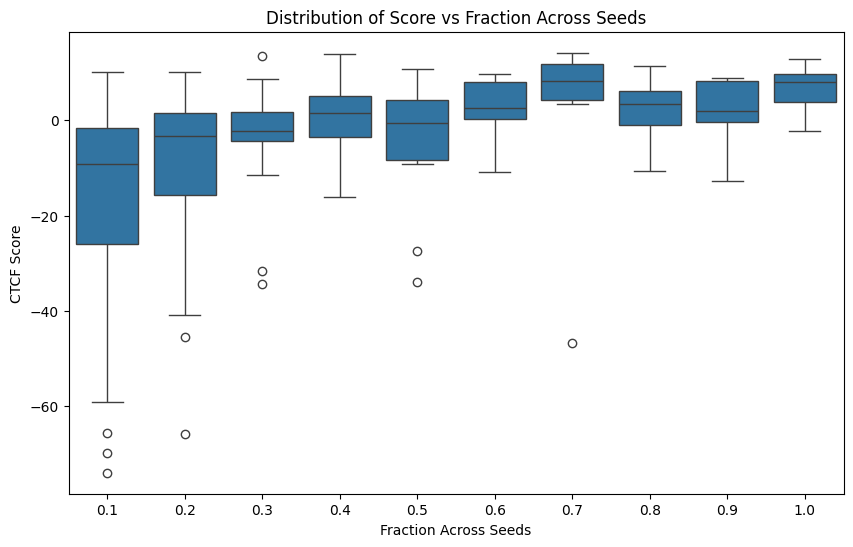

In [51]:
plt.figure(figsize=(10,6))
sns.boxplot(x="fraction_across_seeds", y="score", data=ctcf_seed_counts)
plt.xlabel("Fraction Across Seeds")
plt.ylabel("CTCF Score")
plt.title("Distribution of Score vs Fraction Across Seeds")
plt.show()

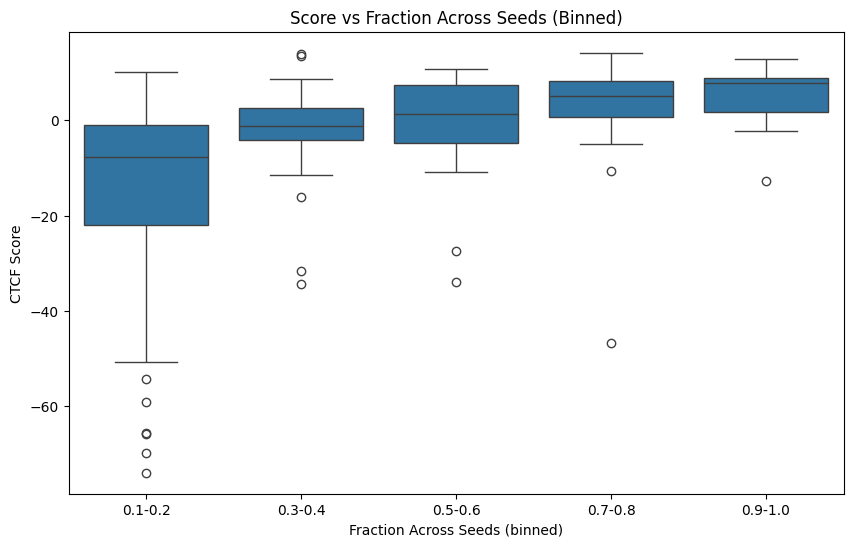

In [52]:
# define bins and labels
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # edges of bins
labels = ["0.1-0.2", "0.3-0.4", "0.5-0.6", "0.7-0.8", "0.9-1.0"]

# create a new binned column
ctcf_seed_counts["fraction_bin"] = pd.cut(ctcf_seed_counts["fraction_across_seeds"], bins=bins, labels=labels)

# boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x="fraction_bin", y="score", data=ctcf_seed_counts)
plt.xlabel("Fraction Across Seeds (binned)")
plt.ylabel("CTCF Score")
plt.title("Score vs Fraction Across Seeds (Binned)")
plt.show()


In [53]:
len(ctcf_seed_counts)

367

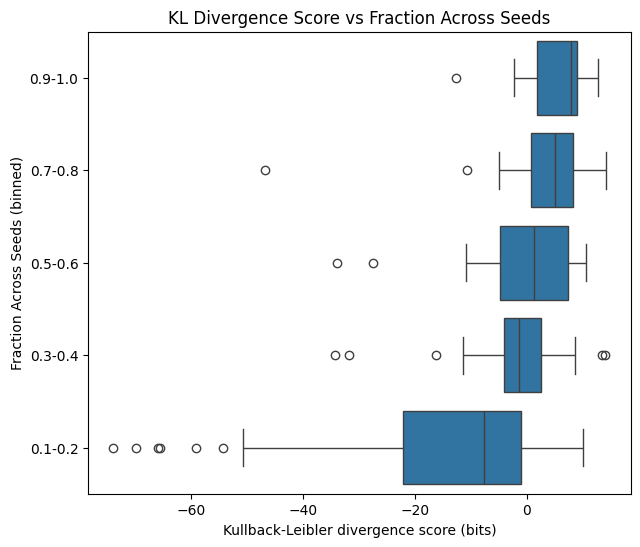

In [54]:
# Reverse the order so higher fractions appear at the top
order = labels[::-1]

plt.figure(figsize=(7,6))
sns.boxplot(
    y="fraction_bin", 
    x="score", 
    data=ctcf_seed_counts,
    orient="h",
    order=order
)

plt.ylabel("Fraction Across Seeds (binned)")
plt.xlabel("Kullback-Leibler divergence score (bits)")
plt.title("KL Divergence Score vs Fraction Across Seeds")
plt.show()

In [55]:
sum_scores_df = (
    ctcf_seed_counts
    .groupby(["chrom", "centered_start", "centered_end"])["score"]
    .sum()
    .reset_index()
    .rename(columns={"score": "sum_score"})
)

In [56]:
merged_df = jaccard_df.merge(
    sum_scores_df, 
    on=["chrom", "centered_start", "centered_end"],
    how="inner"
)

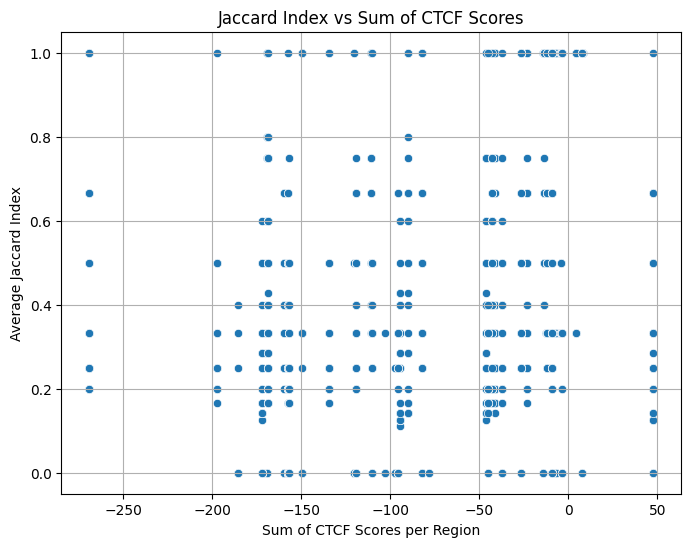

In [57]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="sum_score", y="jaccard", data=merged_df)
plt.xlabel("Sum of CTCF Scores per Region")
plt.ylabel("Average Jaccard Index")
plt.title("Jaccard Index vs Sum of CTCF Scores")
plt.grid(True)
plt.show()

In [58]:
# Define bins and labels
bins = np.linspace(0, 1, 6)  # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

# Create a new binned column
merged_df["jaccard_bin"] = pd.cut(merged_df["jaccard"], bins=bins, labels=labels, include_lowest=True)

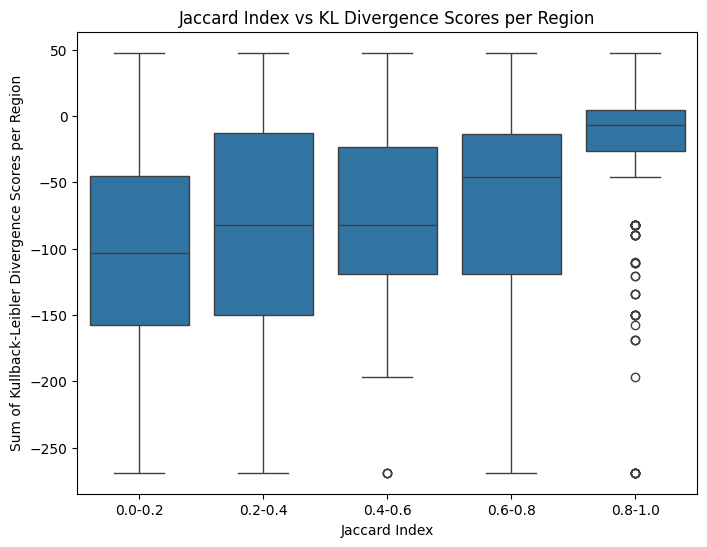

In [59]:
# Boxplot: one box per Jaccard bin
plt.figure(figsize=(8,6))
sns.boxplot(x="jaccard_bin", y="sum_score", data=merged_df)
plt.xlabel("Jaccard Index")
plt.ylabel("Sum of Kullback-Leibler Divergence Scores per Region")
plt.title("Jaccard Index vs KL Divergence Scores per Region")
plt.show()

In [60]:
merged_df

,chrom,centered_start,centered_end,seed1,seed2,jaccard,sum_score,jaccard_bin
0,chr1,37799936,39110656,0,1,0.00,-97.390862,0.0-0.2
1,chr1,37799936,39110656,0,6,0.00,-97.390862,0.0-0.2
2,chr1,37799936,39110656,0,9,0.00,-97.390862,0.0-0.2
3,chr1,37799936,39110656,1,6,0.00,-97.390862,0.0-0.2
4,chr1,37799936,39110656,1,9,0.25,-97.390862,0.2-0.4
...,...,...,...,...,...,...,...,...
1577,chr4,109963264,111273984,3,7,0.00,7.881373,0.0-0.2
1578,chr4,109963264,111273984,3,9,1.00,7.881373,0.8-1.0
1579,chr4,109963264,111273984,4,7,0.00,7.881373,0.0-0.2
1580,chr4,109963264,111273984,4,9,1.00,7.881373,0.8-1.0


In [61]:
present_labels = [lab for lab in labels if lab in merged_df['jaccard_bin'].unique()]

In [62]:
order = present_labels[::-1]

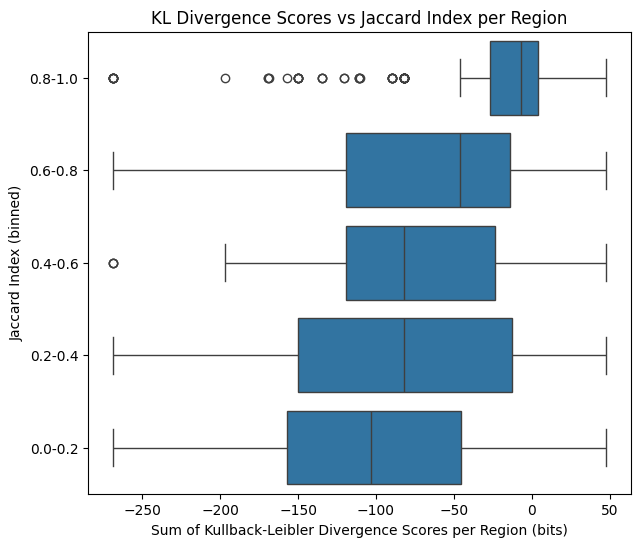

In [63]:
plt.figure(figsize=(7,6))
sns.boxplot(
    x="sum_score", 
    y="jaccard_bin", 
    data=merged_df,
    orient="h",
    order=order
)
plt.xlabel("Sum of Kullback-Leibler Divergence Scores per Region (bits)")
plt.ylabel("Jaccard Index (binned)")
plt.title("KL Divergence Scores vs Jaccard Index per Region")
plt.show()

In [64]:
from scipy.stats import pearsonr

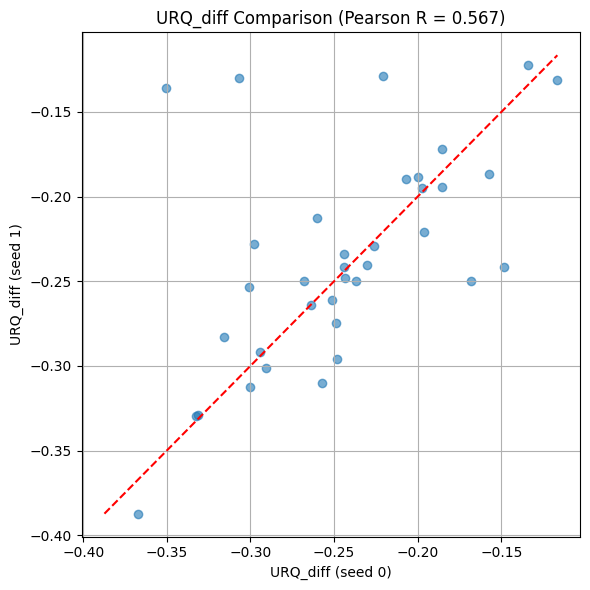

In [67]:
# Pivot to align seed 0 and seed 1 by region
pivot_df = df[df['seed'].isin([0, 1])].pivot_table(
    index=['chrom', 'centered_start', 'centered_end'], 
    columns='seed', 
    values='URQ_diff'
).dropna()

pivot_df.columns = ['seed0', 'seed1']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed0'], pivot_df['seed1'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed0'], pivot_df['seed1'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_diff (seed 0)')
plt.ylabel('URQ_diff (seed 1)')
plt.title(f'URQ_diff Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

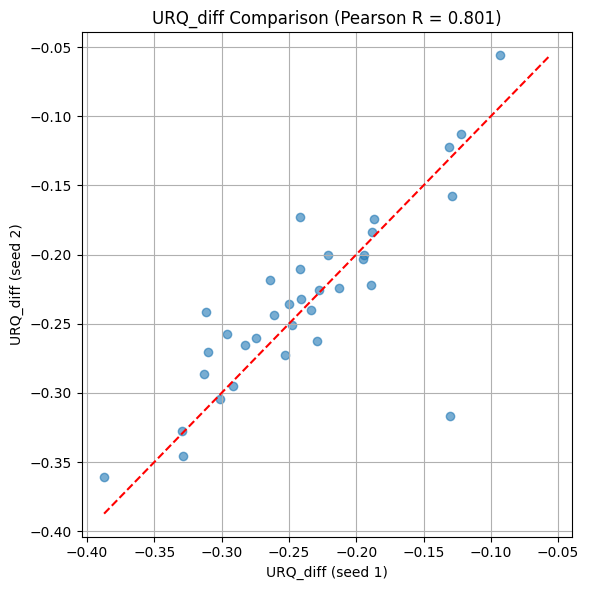

In [68]:
# Pivot to align seed 1 and seed 2 by region
pivot_df = df[df['seed'].isin([1, 2])].pivot_table(
    index=['chrom', 'centered_start', 'centered_end'], 
    columns='seed', 
    values='URQ_diff'
).dropna()

pivot_df.columns = ['seed1', 'seed2']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed1'], pivot_df['seed2'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed1'], pivot_df['seed2'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_diff (seed 1)')
plt.ylabel('URQ_diff (seed 2)')
plt.title(f'URQ_diff Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

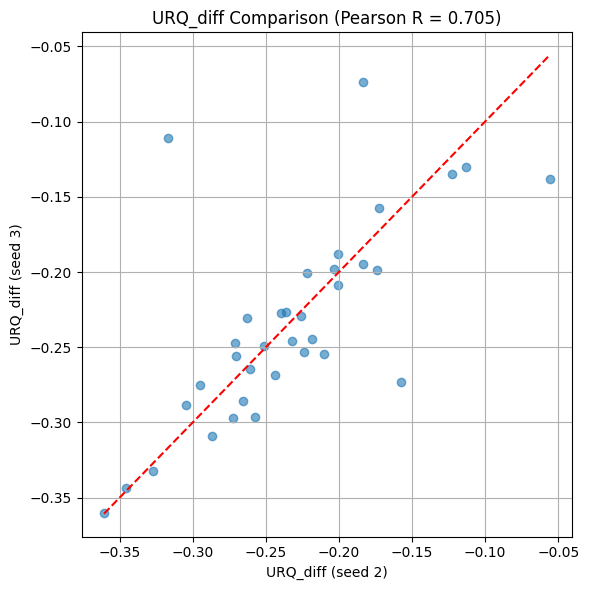

In [69]:
# Pivot to align seed 2 and seed 3 by region
pivot_df = df[df['seed'].isin([2, 3])].pivot_table(
    index=['chrom', 'centered_start', 'centered_end'], 
    columns='seed', 
    values='URQ_diff'
).dropna()

pivot_df.columns = ['seed2', 'seed3']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed2'], pivot_df['seed3'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed2'], pivot_df['seed3'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_diff (seed 2)')
plt.ylabel('URQ_diff (seed 3)')
plt.title(f'URQ_diff Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

In [70]:
region_cols = ['chrom', 'centered_start', 'centered_end']
aligned_df = df.pivot_table(index=region_cols, columns='seed', values=['orientation', 'positions'], aggfunc='first')
aligned_df = aligned_df.dropna()  # keep only complete pairs

In [ ]:
# aligned_df

In [71]:
region = ('chr5', 38354944, 39665664)
region_df = df[
    (df['chrom'] == region[0]) &
    (df['centered_start'] == region[1]) &
    (df['centered_end'] == region[2])]

In [72]:
len(region_df)

9

In [73]:
from matplotlib.patches import FancyArrow, Patch, Rectangle
import ast

In [74]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.ndimage import gaussian_filter1d

In [75]:
# --- Parse positions ---
region_df['positions'] = region_df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# --- Parameters ---
region_length = 2048
flank = 60
total_length = region_length + 2 * flank
bins = np.arange(-flank, region_length + flank + 1, 10)  # 10 bp resolution

# --- Build numeric orientation tracks for each seed ---
tracks = []
seed_ids = []

for seed in sorted(region_df['seed'].unique()):
    row = region_df[region_df['seed'] == seed].iloc[0]
    signal = np.zeros(len(bins))
    for (start, end), ori in zip(row['positions'], row['orientation']):
        # Clip to within flanked region
        start = max(-flank, min(start, region_length + flank))
        pos_idx = np.argmin(np.abs(bins - start))
        signal[pos_idx] = 1 if ori == '+' else -1
    # Smooth a bit to tolerate small positional shifts
    signal = gaussian_filter1d(signal, sigma=1)
    tracks.append(signal)
    seed_ids.append(seed)

tracks = np.array(tracks)

# --- Cluster by spatial similarity ---
dist = pdist(tracks, metric='cosine')
link = linkage(dist, method='average')
cluster_order = leaves_list(link)
seed_order = [seed_ids[i] for i in cluster_order]

/tmp/SLURM_2083474/ipykernel_758396/2677005341.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['positions'] = region_df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


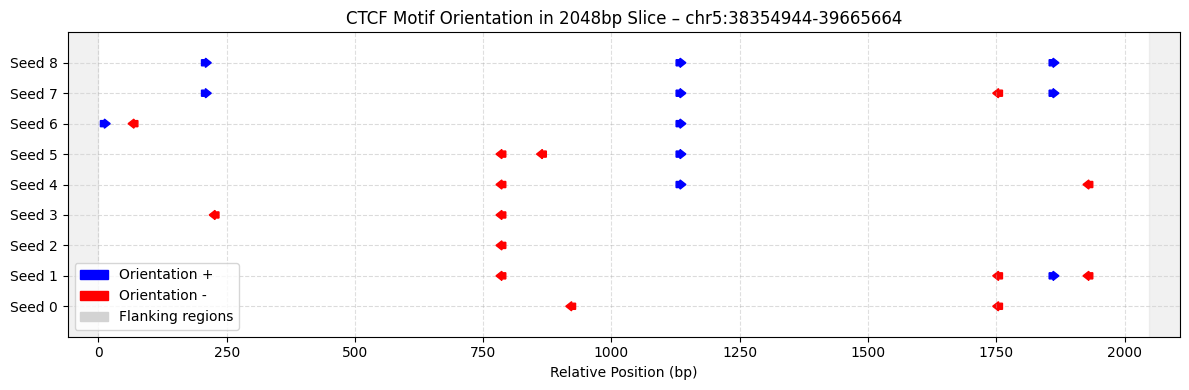

In [76]:
# --- Plot setup ---
fig, ax = plt.subplots(figsize=(12, 4))  # taller for more rows
y_positions = {seed: idx for idx, seed in enumerate(seed_order)}  # top-down: 5 → 0

# --- Draw grey flanks ---
ax.add_patch(Rectangle((-60, -1), 60, len(seed_order) + 1, color='lightgrey', alpha=0.3, zorder=0))
ax.add_patch(Rectangle((2048, -1), 60, len(seed_order) + 1, color='lightgrey', alpha=0.3, zorder=0))

# --- Dashed baseline for each row ---
for seed in seed_order:
    y = y_positions[seed]
    ax.plot([-flank, region_length + flank], [y, y],
            color='lightgrey', linewidth=0.8, linestyle='--', alpha=0.8, zorder=1)

# --- Draw motifs ---
for _, row in region_df.iterrows():
    seed = row['seed']
    y = y_positions[seed]
    positions = row['positions']
    orientations = row['orientation']
    
    for (start, end), ori in zip(positions, orientations):
        color = 'blue' if ori == '+' else 'red'
        direction = 1 if ori == '+' else -1
        width = end - start
        arrow = FancyArrow(start, y, width * direction, 0,
                           width=0.2,
                           head_width=0.3,
                           head_length=min(20, width * 0.6),
                           length_includes_head=True,
                           color=color)
        ax.add_patch(arrow)

# --- Axis settings ---
ax.set_xlim(-60, 2108)
ax.set_ylim(-1, len(seed_order))
ax.set_yticks([y_positions[s] for s in seed_order])
ax.set_yticklabels([f'Seed {s}' for s in [i for i in range(9)]])
ax.set_xlabel('Relative Position (bp)')
ax.set_title(f"CTCF Motif Orientation in 2048bp Slice – {region[0]}:{region[1]}-{region[2]}")
ax.grid(axis='x', linestyle='--', alpha=0.4)

# --- Legend ---
legend_handles = [
    Patch(color='blue', label='Orientation +'),
    Patch(color='red', label='Orientation -'),
    Patch(color='lightgrey', label='Flanking regions')
]

ax.legend(handles=legend_handles, loc='lower left')

plt.tight_layout()

# --- Save as SVG ---
# plt.savefig("ctcf_seeds_orientations.svg", format="svg", bbox_inches="tight")

plt.show()


### Check underlying sequence

In [ ]:
# df

In [ ]:
chrom = "chr5"
start = 38354944
end = 39665664	

In [ ]:
path_to_ohe_seq = f"/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold0/{chrom}_{start}_{end}_X.pt"

In [ ]:
import torch

In [ ]:
ohe = torch.load(path_to_ohe_seq)

In [ ]:
central_bin = 256
cropping = 64
bins_size = 2048

In [ ]:
scanned_slice_start = ((central_bin + cropping) * bins_size)

In [ ]:
scanned_slice_end = ((central_bin + cropping + 1) * bins_size)

In [ ]:
ohe_slice = ohe[:, :, scanned_slice_start:scanned_slice_end]

In [ ]:
for element in region_df["positions"]:
    print(element)

In [ ]:
# check_for_ctcf = ohe_slice[0, :, 794:813]
check_for_ctcf = ohe_slice[0, :, 1126:1145]

check_for_ctcf_np = check_for_ctcf.numpy()

In [ ]:
def decode_ohe_dna(ohe_array, reverse_complement=False):
    """
    Decode a one-hot encoded DNA array (shape: 4 x seq_len) into a string.
    If reverse_complement=True, returns the reverse complement of the sequence.
    """
    # Map from channel index to base
    index_to_base = ['A', 'C', 'G', 'T']
    
    # Decode from one-hot
    base_indices = np.argmax(ohe_array, axis=0)
    sequence = ''.join(index_to_base[i] for i in base_indices)
    
    if reverse_complement:
        # Define complement map
        complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
        sequence = ''.join(complement[base] for base in reversed(sequence))
    
    return sequence

In [ ]:
# decoded = decode_ohe_dna(check_for_ctcf_np, reverse_complement=True)
decoded = decode_ohe_dna(check_for_ctcf_np, reverse_complement=False)

In [ ]:
decoded_sequence = ''.join(decoded)
print(decoded_sequence)